<a href="https://colab.research.google.com/github/rajeeakbar/The-Market-Gap-Analysis/blob/main/Market_Gap_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone my forked repository
!git clone https://github.com/rajeeakbar/The-Market-Gap-Analysis.git

Cloning into 'The-Market-Gap-Analysis'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 13 (delta 2), reused 2 (delta 2), pack-reused 9 (from 1)
Receiving objects: 100% (13/13), 9.84 KiB | 4.92 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [2]:
# Mount Google Drive to save my work
from google.colab import drive
drive.mount('/content/drive')

#Clone my forked repository
!git clone https://github.com/rajeeakbar/The-Market-Gap-Analysis

# Move into that folder
import os
os.chdir('/content/The-Market-Gap-Analysis')
print("Current directory:", os.getcwd())

Mounted at /content/drive
fatal: destination path 'The-Market-Gap-Analysis' already exists and is not an empty directory.
Current directory: /content/The-Market-Gap-Analysis


In [4]:
# Step 2: lets Download a clean pre-filtered sample to bypasses the broken CSV file
!wget -O products.csv.gz "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

# Step 3: Load with correct parameters
import pandas as pd

df = pd.read_csv(
    'products.csv.gz',
    compression='gzip',
    nrows=150000,
    on_bad_lines='skip',
    sep='\t',  # <-- KEY: Open Food Facts uses tab, not comma!
    encoding='utf-8'
)

print(df.shape)
print(df.columns.tolist()[:10])

--2026-05-28 15:38:12--  https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz
Resolving static.openfoodfacts.org (static.openfoodfacts.org)... 151.115.132.10
Connecting to static.openfoodfacts.org (static.openfoodfacts.org)|151.115.132.10|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz [following]
--2026-05-28 15:38:12--  https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz
Resolving openfoodfacts-ds.s3.eu-west-3.amazonaws.com (openfoodfacts-ds.s3.eu-west-3.amazonaws.com)... 3.5.205.146, 3.5.206.249
Connecting to openfoodfacts-ds.s3.eu-west-3.amazonaws.com (openfoodfacts-ds.s3.eu-west-3.amazonaws.com)|3.5.205.146|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1275171186 (1.2G) [application/gzip]
Saving to: ‘products.csv.gz’

products.csv.gz     100%[===================>]  

/tmp/ipykernel_3806/1163540873.py:7: DtypeWarning: Columns (11,17,34,36,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


(150000, 211)
['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'last_modified_by', 'last_updated_t', 'last_updated_datetime']


In [7]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
#  Clean the data to keep only relevant columns
keep_cols = ['product_name', 'sugars_100g', 'proteins_100g', 'categories_tags', 'ingredients_text']
df_clean = df[keep_cols].copy()

print(f"Before cleaning: {len(df_clean)} rows")

# Remove missing values in key columns
df_clean = df_clean.dropna(subset=['sugars_100g', 'proteins_100g'])

# Remove outliers (biologically impossible values)
df_clean = df_clean[
    (df_clean['sugars_100g'] >= 0) &
    (df_clean['sugars_100g'] <= 100) &
    (df_clean['proteins_100g'] >= 0) &
    (df_clean['proteins_100g'] <= 100)
]

print(f"After cleaning: {len(df_clean)} rows")
print(f"Data cleaned")

Before cleaning: 150000 rows
After cleaning: 27218 rows
Data cleaned


In [21]:
# Assign high-level categories
import numpy as np

def assign_category(tag_string):
    if not isinstance(tag_string, str):
        return 'Other'

    tags = tag_string.lower()

    if 'chocolate' in tags or 'candy' in tags or 'sweet' in tags or 'confectionery' in tags:
        return 'Confectionery & Sweets'
    elif 'cookie' in tags or 'biscuit' in tags or 'cracker' in tags or 'wafer' in tags:
        return 'Cookies & Biscuits'
    elif 'chip' in tags or 'crisp' in tags or 'snack' in tags or 'pretzel' in tags or 'popcorn' in tags:
        return 'Savory Snacks'
    elif 'protein' in tags or 'bar' in tags or 'energy bar' in tags or 'fitness' in tags:
        return 'Protein & Energy Bars'
    elif 'nut' in tags or 'seed' in tags or 'almond' in tags or 'peanut' in tags or 'cashew' in tags:
        return 'Nuts & Seeds'
    elif 'fruit' in tags or 'berry' in tags or 'dried fruit' in tags:
        return 'Dried Fruit'
    elif 'yogurt' in tags or 'dairy' in tags or 'cheese' in tags or 'milk' in tags:
        return 'Dairy Snacks'
    else:
        return 'Other'

df_clean['primary_category'] = df_clean['categories_tags'].apply(assign_category)

print("Category distribution:")
print(df_clean['primary_category'].value_counts())
print(f"\n{df_clean['primary_category'].nunique()} categories created")

Category distribution:
primary_category
Other                     20766
Confectionery & Sweets     2046
Dairy Snacks               1321
Dried Fruit                1035
Savory Snacks              1020
Nuts & Seeds                642
Protein & Energy Bars       245
Cookies & Biscuits          143
Name: count, dtype: int64

8 categories created


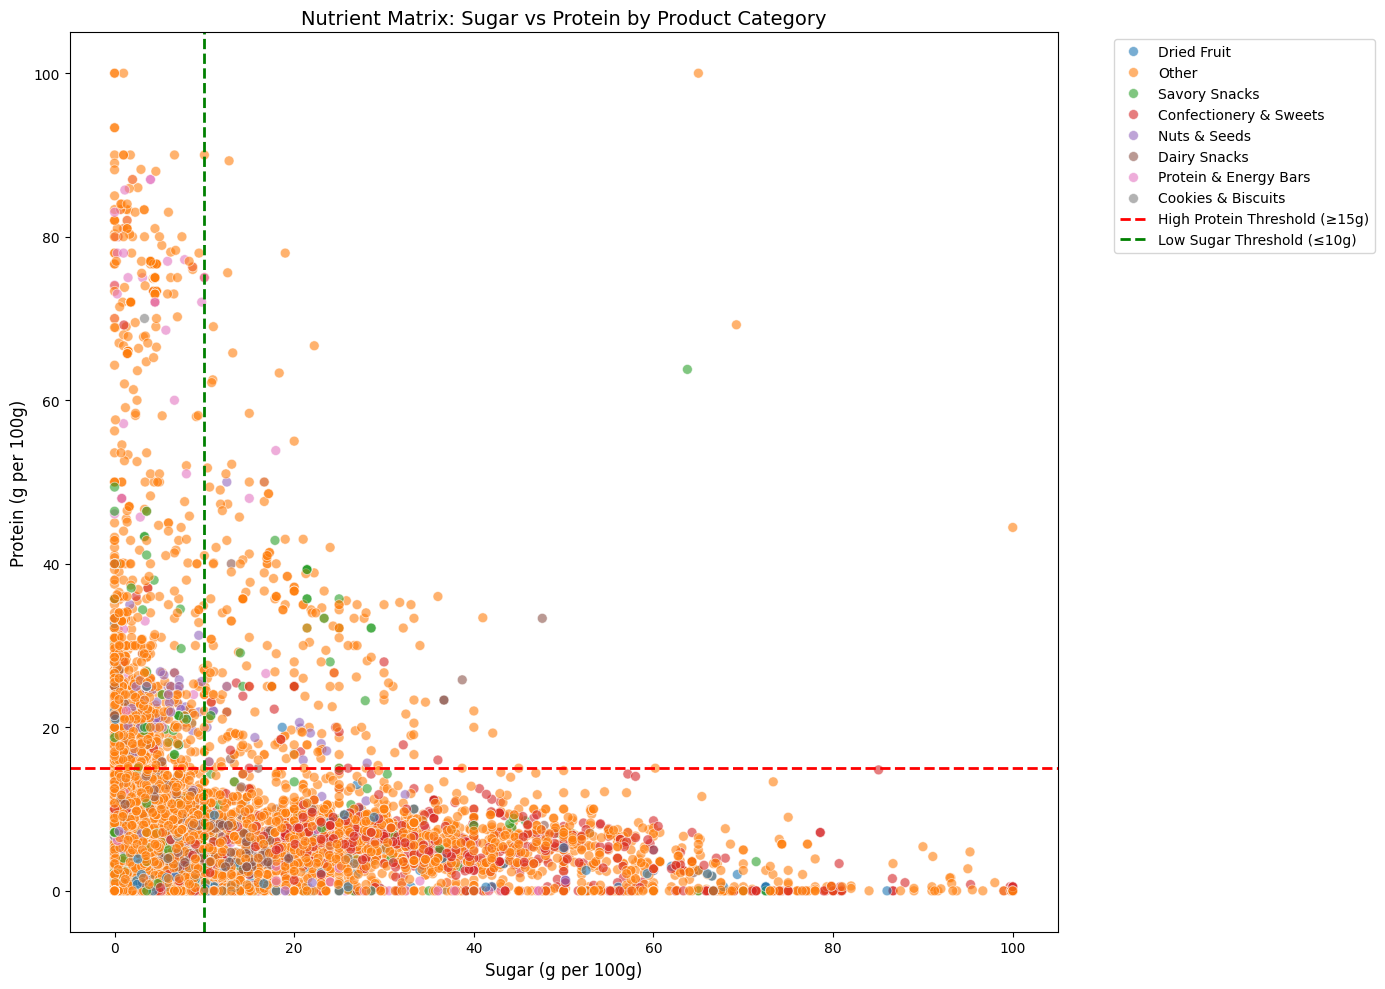

Scatter plot created
The bottom-right quadrant (high protein + low sugar) is the market opportunity


In [22]:
# Create Nutrient Matrix Scatter Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Sample for faster plotting (10,000 points is plenty)
plot_df = df_clean.sample(min(10000, len(df_clean)))

plt.figure(figsize=(14, 10))

# Create scatter plot
sns.scatterplot(
    data=plot_df,
    x='sugars_100g',
    y='proteins_100g',
    hue='primary_category',
    alpha=0.6,
    s=50
)

# Add threshold lines for "Empty Quadrant"
plt.axhline(y=15, color='red', linestyle='--', linewidth=2, label='High Protein Threshold (≥15g)')
plt.axvline(x=10, color='green', linestyle='--', linewidth=2, label='Low Sugar Threshold (≤10g)')

# Labels and title
plt.xlabel('Sugar (g per 100g)', fontsize=12)
plt.ylabel('Protein (g per 100g)', fontsize=12)
plt.title('Nutrient Matrix: Sugar vs Protein by Product Category', fontsize=14)

# Legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print("Scatter plot created")
print("The bottom-right quadrant (high protein + low sugar) is the market opportunity")

In [26]:
# Find the market opportunity
# Define "opportunity zone": High Protein (≥15g) + Low Sugar (≤10g)
opportunity_zone = df_clean[
    (df_clean['proteins_100g'] >= 15) &
    (df_clean['sugars_100g'] <= 10)
]

print(f"Products in opportunity zone: {len(opportunity_zone)}")
print("\nCategories in opportunity zone:")
print(opportunity_zone['primary_category'].value_counts())

# Find the best category
top_category = opportunity_zone['primary_category'].value_counts().index[0]
top_products = opportunity_zone[opportunity_zone['primary_category'] == top_category]

avg_protein = top_products['proteins_100g'].mean()
avg_sugar = top_products['sugars_100g'].mean()

print("\n" + "="*60)
print(" RECOMMENDATION")
print("="*60)
print(f"Based on the data, the biggest market opportunity is in {top_category}, specifically targeting products with {avg_protein:.1f}g of protein and less than {avg_sugar:.1f}g of sugar.")
print("="*60)


Products in opportunity zone: 4256

Categories in opportunity zone:
primary_category
Other                     3518
Nuts & Seeds               214
Dairy Snacks               192
Savory Snacks              142
Protein & Energy Bars      134
Confectionery & Sweets      36
Dried Fruit                 15
Cookies & Biscuits           5
Name: count, dtype: int64

 RECOMMENDATION
Based on the data, the biggest market opportunity is in Other, specifically targeting products with 31.1g of protein and less than 2.1g of sugar.


In [29]:
# Find top protein ingredients
import re
from collections import Counter

# Get high-protein products (≥15g protein)
high_protein = df_clean[df_clean['proteins_100g'] >= 15].copy()

# Known protein sources (common in food products)
protein_keywords = ['whey', 'soy', 'pea', 'milk', 'egg', 'almond', 'peanut', 'cashew',
                    'chia', 'hemp', 'sunflower', 'pumpkin seed', 'cocoa', 'gelatin',
                    'collagen', 'casein', 'lentil', 'bean', 'quinoa', 'oat']

def extract_protein_sources(ingredients_text):
    if not isinstance(ingredients_text, str):
        return []
    text = ingredients_text.lower()
    found = []
    for source in protein_keywords:
        if source in text:
            found.append(source)
    return found

# Extract from all high-protein products
all_sources = []
for ingredients in high_protein['ingredients_text']:
    all_sources.extend(extract_protein_sources(ingredients))

# Get top 3
top_sources = Counter(all_sources).most_common(3)

print("\nTop 3 Protein Sources in High-Protein Products")
print("-" * 50)
for i, (source, count) in enumerate(top_sources, 1):
    print(f"{i}. {source.title()} (appears in {count} products)")



Top 3 Protein Sources in High-Protein Products
--------------------------------------------------
1. Milk (appears in 391 products)
2. Soy (appears in 386 products)
3. Pea (appears in 222 products)


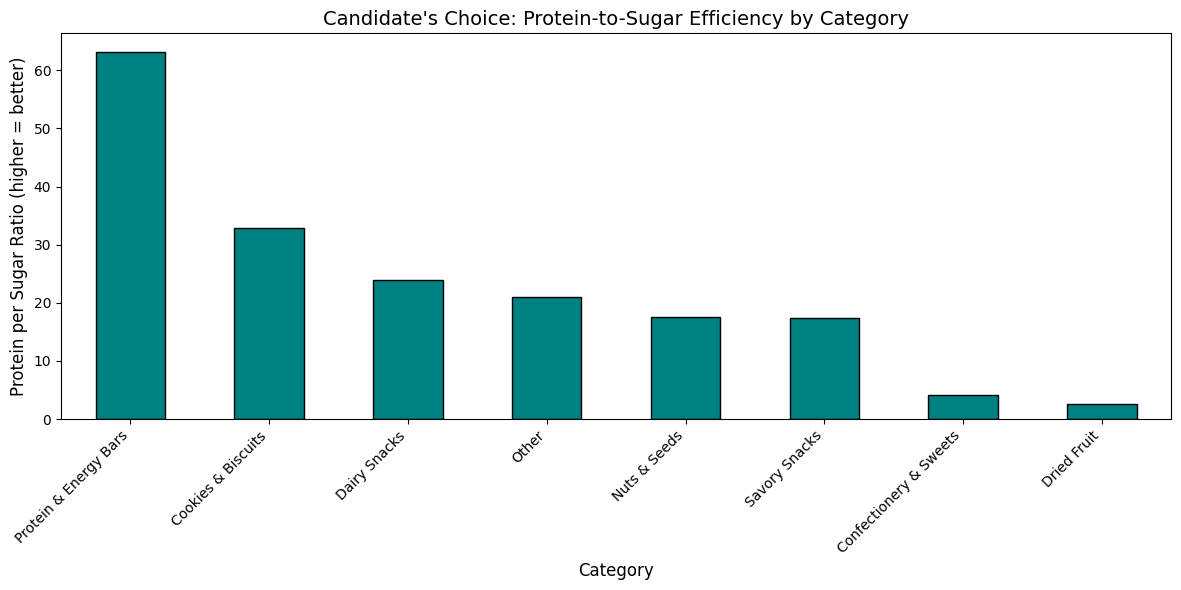


An Explanation of my Choice :
--------------------------------------------------
What I added: Protein-to-Sugar Efficiency Ratio
Why it matters: Most consumers want high protein WITHOUT high sugar.
Business value: This identifies which categories deliver the best nutritional value
Top performer: Protein & Energy Bars (Ratio: 63.20)


In [33]:
# My Choice (Protein Efficiency Ratio to Show which category gives most protein per gram of sugar)

# Calculate ratio (add 0.1 to avoid division by zero)
df_clean['protein_sugar_ratio'] = df_clean['proteins_100g'] / (df_clean['sugars_100g'] + 0.1)

# Average ratio by category
ratio_by_category = df_clean.groupby('primary_category')['protein_sugar_ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ratio_by_category.plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Protein per Sugar Ratio (higher = better)', fontsize=12)
plt.title("Candidate's Choice: Protein-to-Sugar Efficiency by Category", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nAn Explanation of my Choice :")
print("-" * 50)
print("What I added: Protein-to-Sugar Efficiency Ratio")
print("Why it matters: Most consumers want high protein WITHOUT high sugar.")
print("Business value: This identifies which categories deliver the best nutritional value")
print(f"Top performer: {ratio_by_category.index[0]} (Ratio: {ratio_by_category.iloc[0]:.2f})")

In [38]:
# Saving cleaned data for dashboard
df_clean.to_csv('healthy_snack_data.csv', index=False)
from google.colab import files
files.download('healthy_snack_data.csv')

print("CSV downloaded")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV downloaded
